# Data cleaning

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
# reading the enhanced dataset with additional features from pretainingimproving features notebook
data= pd.read_csv("enhanced_football_data.csv",parse_dates=['date'])

In [26]:
data.isna().sum()

home_form               0
away_form               1
home_avg_goals          0
away_avg_goals          1
result                  0
form_diff               1
goal_diff_avg           1
date                    0
home_team               0
away_team               0
home_team_goal          0
away_team_goal          0
home_avg_conceded     972
away_avg_conceded     972
goal_diff_form       1308
home_win_rate           0
away_win_rate           1
win_rate_diff           1
dtype: int64

In [27]:
data[data.isna().any(axis=1)]
data.dropna(inplace=True)
data.reset_index(drop=True, inplace=True)

In [28]:
data.isna().sum()

home_form            0
away_form            0
home_avg_goals       0
away_avg_goals       0
result               0
form_diff            0
goal_diff_avg        0
date                 0
home_team            0
away_team            0
home_team_goal       0
away_team_goal       0
home_avg_conceded    0
away_avg_conceded    0
goal_diff_form       0
home_win_rate        0
away_win_rate        0
win_rate_diff        0
dtype: int64

# EDA

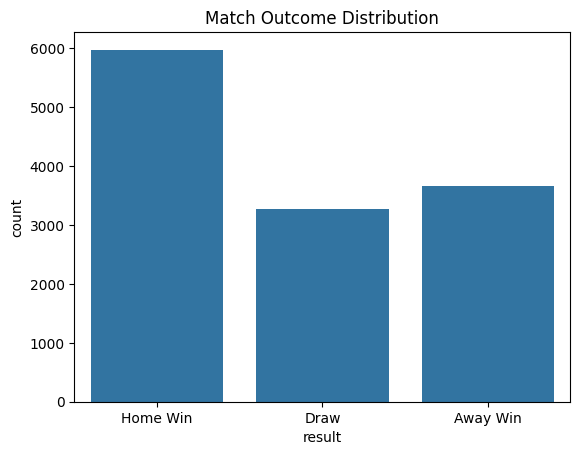

In [29]:
#applying some EDA to see if the new features have any correlation with the result
sns.countplot(x='result', data=data)
plt.title("Match Outcome Distribution")
plt.xticks([0,1,2], ['Home Win', 'Draw', 'Away Win'])
plt.show()

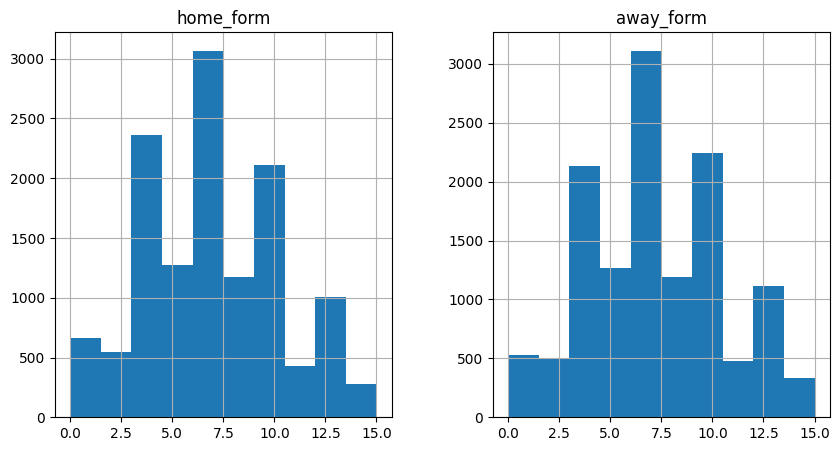

In [30]:
data[['home_form','away_form']].hist(figsize=(10,5))
plt.show()

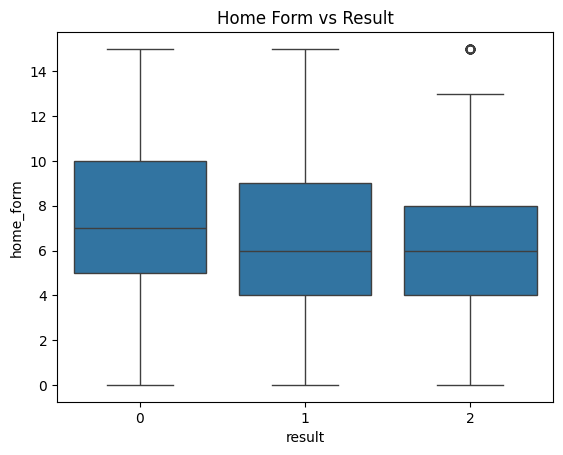

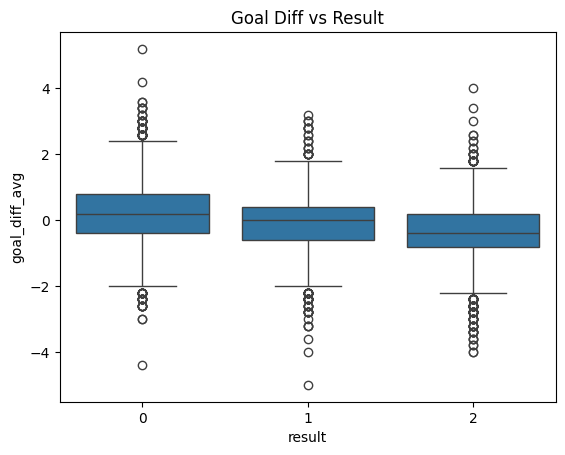

In [31]:
#form vs result
sns.boxplot(x='result', y='home_form', data=data)
plt.title("Home Form vs Result")
plt.show()

#goal vs result
sns.boxplot(x='result', y='goal_diff_avg', data=data)
plt.title("Goal Diff vs Result")
plt.show()

In [32]:
# outliers are not handled because it shows high goal wins, so we will keep them as they are important for the model to learn the patterns of high scoring matches

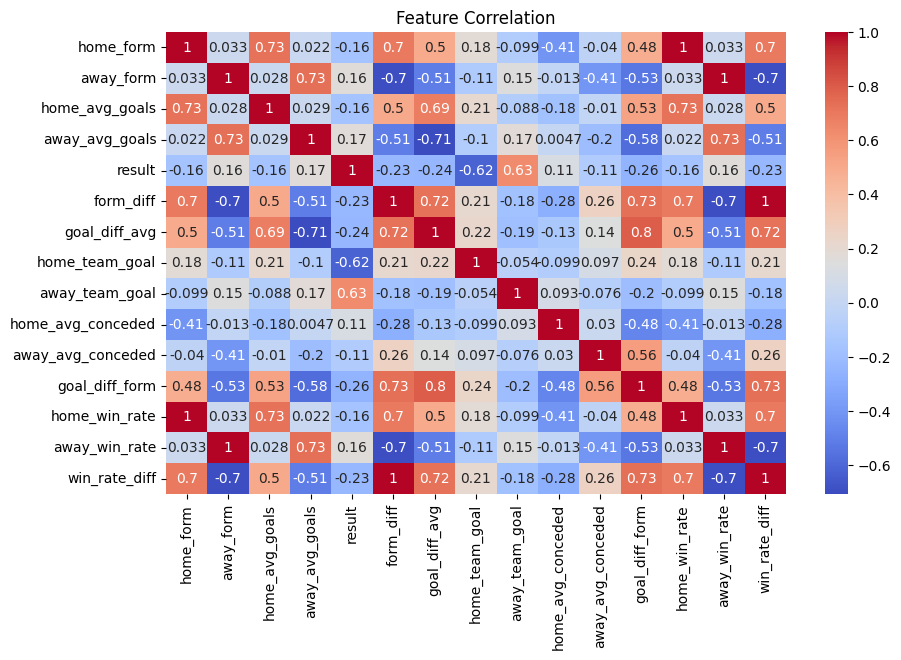

In [33]:
#correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

In [34]:
home_wins = (data['result'] == 0).sum()
away_wins = (data['result'] == 2).sum()

print("Home Wins:", home_wins)
print("Away Wins:", away_wins)
print('home wins are more than away wins, which is expected in football due to home advantage')

Home Wins: 5978
Away Wins: 3660
home wins are more than away wins, which is expected in football due to home advantage


In [35]:
features = [
    'form_diff',
    'goal_diff_avg',
    'goal_diff_form',
    'win_rate_diff'
]
X = data[features]
y = data['result']

In [36]:
#train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# model

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
# retrain models with new features
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        objective='multi:softmax',
        eval_metric='mlogloss'
    )
}
results = {}
for name, model in models.items():
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"{name} Accuracy: {acc:.4f}")

Logistic Regression Accuracy: 0.4872
Random Forest Accuracy: 0.4791
XGBoost Accuracy: 0.4775


In [38]:
#grid search 
from sklearn.model_selection import GridSearchCV
rf = RandomForestClassifier(random_state=42)
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)
print("Best RF Params:", grid_rf.best_params_)
print("Best RF Score:", grid_rf.best_score_)

Best RF Params: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best RF Score: 0.49191453025782944


In [39]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'subsample': [0.7, 0.8, 1],
    'colsample_bytree': [0.7, 0.8, 1]
}

random_search = RandomizedSearchCV(
    XGBClassifier(),
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Params:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Best Params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Best Score: 0.4928830157206185


In [40]:
# best model
# from grid search in randomforest 
# from random search in xgboost
best_rf = grid_rf.best_estimator_
best_xgb = random_search.best_estimator_

In [41]:
#evaluating the best model on test set
# Random Forest
rf_pred = best_rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

# XGBoost
xgb_pred = best_xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)

print("Random Forest Test Accuracy:", rf_acc)
print("XGBoost Test Accuracy:", xgb_acc)

Random Forest Test Accuracy: 0.4868319132455461
XGBoost Test Accuracy: 0.4856700232378002


In [42]:

comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'CV Score': [grid_rf.best_score_, random_search.best_score_],
    'Test Accuracy': [rf_acc, xgb_acc]
})

print(comparison)

           Model  CV Score  Test Accuracy
0  Random Forest  0.491915       0.486832
1        XGBoost  0.492883       0.485670


In [43]:
if xgb_acc > rf_acc:
    best_model = best_xgb
    best_name = "XGBoost"
else:
    best_model = best_rf
    best_name = "Random Forest"

print("Best Model Selected:", best_name)

Best Model Selected: Random Forest


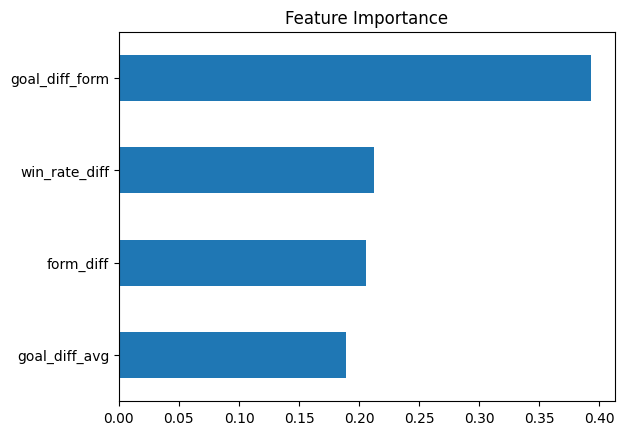

In [44]:
# feature importance for the best model
importance = pd.Series(best_model.feature_importances_, index=features)

importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

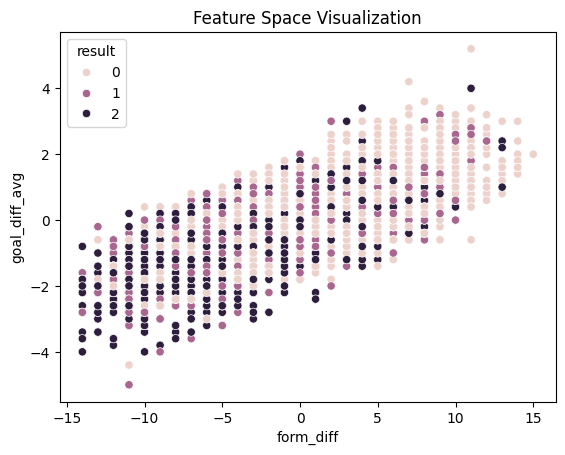

In [45]:
sns.scatterplot(
    x='form_diff',
    y='goal_diff_avg',
    hue='result',
    data=data
)
plt.title("Feature Space Visualization")
plt.show()

# deployment

In [46]:
import joblib

joblib.dump(best_model, "football_model.pkl")

['football_model.pkl']

In [47]:
features = ['form_diff', 'goal_diff_avg', 'goal_diff_form', 'win_rate_diff']

joblib.dump(features, "features.pkl")

['features.pkl']

In [48]:
data.to_csv("processed_matches.csv", index=False)